In [48]:
!pip install -qq gensim

# Skip-Gram on Shakespeare using Gensim + t-SNE visualisation

In [49]:
import random
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import shakespeare
from gensim.models import Word2Vec
from sklearn.manifold import TSNE

from xml.etree import ElementTree as ET

# -----------------------------
# Reproducibility
# -----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Download Shakespeare corpus

In [50]:
nltk.download("shakespeare")
nltk.download("punkt")
nltk.download("punkt_tab", quiet=True)

[nltk_data] Downloading package shakespeare to /root/nltk_data...
[nltk_data]   Package shakespeare is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

# Load Shakespeare corpus

In [51]:
# This uses all files available in nltk.corpus.shakespeare
raw_text_parts = []

for file_id in shakespeare.fileids():
    xml_content = shakespeare.raw(file_id)

    try:
        root = ET.fromstring(xml_content)

        # Extract only spoken text (lines in plays)
        for elem in root.iter():
            if elem.text:
                raw_text_parts.append(elem.text)

    except:
        continue

raw_text = "\n".join(raw_text_parts)

print("Number of Shakespeare files used:", len(shakespeare.fileids()))
print("Files:", shakespeare.fileids()[:10], "..." if len(shakespeare.fileids()) > 10 else "")
print("Total characters in corpus:", len(raw_text))

Number of Shakespeare files used: 8
Files: ['a_and_c.xml', 'dream.xml', 'hamlet.xml', 'j_caesar.xml', 'macbeth.xml', 'merchant.xml', 'othello.xml', 'r_and_j.xml'] 
Total characters in corpus: 1051373


# Sentence splitting and tokenisation

In [52]:
# Sentence split using line breaks and punctuation as rough boundaries
rough_sentences = re.split(r"[.\n!?;:]+", raw_text)

tokenized_corpus = []
for sent in rough_sentences:
    sent = sent.lower()
    # keep alphabetic tokens and apostrophes inside words
    tokens = re.findall(r"[a-z]+(?:'[a-z]+)?", sent)
    if len(tokens) >= 3:
        tokenized_corpus.append(tokens)

print("Number of tokenised sentences:", len(tokenized_corpus))
print("Example sentence:", tokenized_corpus[0][:15] if tokenized_corpus else "No sentences found")

Number of tokenised sentences: 28762
Example sentence: ['the', 'tragedy', 'of', 'antony', 'and', 'cleopatra']


# Train Skip-Gram model

In [53]:
embedding_size = 100
number_of_neighbours = 5
minimum_appearences = 5
number_of_negative_samples = 10
number_of_CPU_threads = 4
epochs = 1+0

model = Word2Vec(
    sentences=tokenized_corpus,
    vector_size=embedding_size,
    window=number_of_neighbours,
    min_count=minimum_appearences,
    sg=1,                 # 1 = Skip-Gram
    negative=number_of_negative_samples,
    workers=number_of_CPU_threads,
    epochs=epochs,
    seed=SEED
)

print("\nVocabulary size:", len(model.wv.index_to_key))


Vocabulary size: 2998


The Word2Vec model is configured through several parameters that control how word embeddings are learned from the corpus. The sentences argument provides the tokenized text used for training. The vector_size determines the dimensionality of the word embeddings, balancing expressive power and computational cost. The window defines the size of the context window, specifying how many neighbouring words on either side are considered during training. The min_count parameter filters out rare words that appear fewer than the specified number of times, helping to reduce noise and improve stability. Setting sg=1 selects the Skip-Gram architecture (as opposed to CBOW when sg=0). The negative parameter specifies the number of negative samples used during training, enabling efficient approximation of the softmax objective. The workers parameter controls parallelism by setting the number of CPU threads used. The epochs define how many times the model iterates over the entire corpus, influencing convergence. Finally, the seed ensures reproducibility by fixing the random initialization of weights and sampling processes. Together, these parameters determine both the quality and efficiency of the learned word embeddings.

# Show the most frequent words

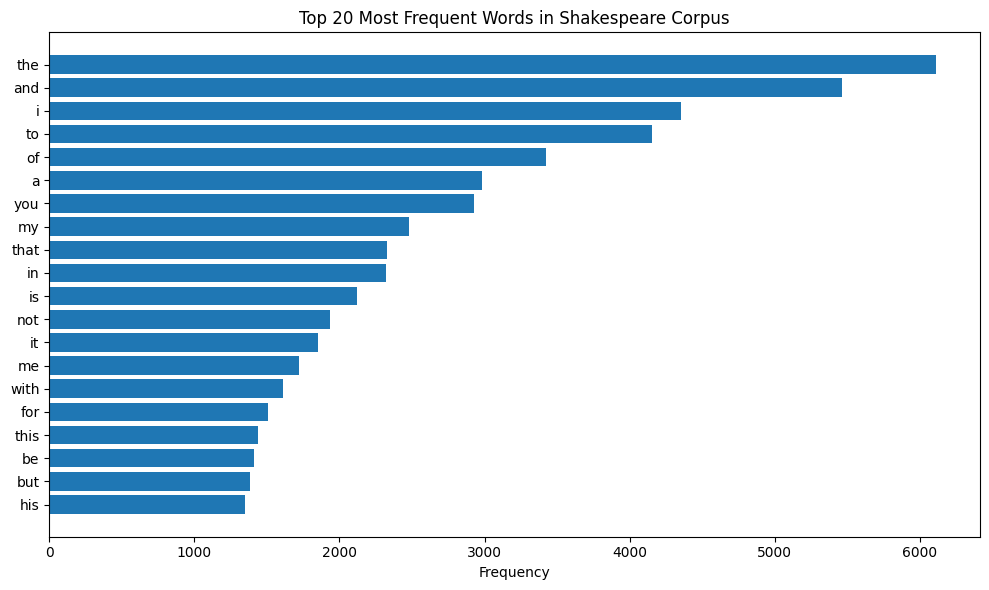

In [54]:
import matplotlib.pyplot as plt
from collections import Counter

number_of_words_to_display = 20

# Get word counts from model
word_counts = model.wv.get_vecattr

# Extract top n words with frequencies
top_words = model.wv.index_to_key[:number_of_words_to_display]
frequencies = [model.wv.get_vecattr(word, "count") for word in top_words]

# Create horizontal bar chart
plt.figure(figsize=(10, 6))
plt.barh(top_words[::-1], frequencies[::-1])  # reverse for top at top

plt.xlabel("Frequency")
plt.title(f"Top {number_of_words_to_display} Most Frequent Words in Shakespeare Corpus")

plt.tight_layout()
plt.show()

# Remove Stop Words and then find the frequent words

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


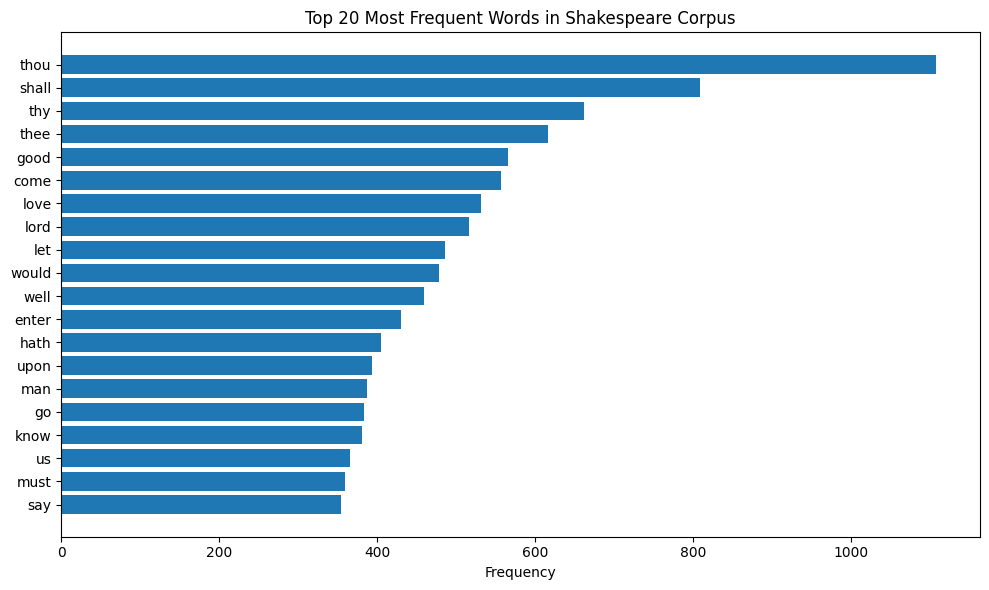

In [55]:
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

filtered_words = [
    w for w in model.wv.index_to_key
    if w not in stop_words and w.isalpha()
]

top_words = filtered_words[:number_of_words_to_display]
frequencies = [model.wv.get_vecattr(word, "count") for word in top_words]

# Create horizontal bar chart
plt.figure(figsize=(10, 6))
plt.barh(top_words[::-1], frequencies[::-1])  # reverse for top at top

plt.xlabel("Frequency")
plt.title(f"Top {number_of_words_to_display} Most Frequent Words in Shakespeare Corpus")

plt.tight_layout()
plt.show()

# Show nearest neighbours for a few sample words

In [56]:
from prettytable import PrettyTable

print("\nNearest neighbours for selected words:")

table = PrettyTable()
table.field_names = ["Target Word", "Neighbour", "Similarity"]

probe_words = random.sample(eligible_words, min(number_of_neighbours, len(eligible_words)))

for word in probe_words:
    neighbours = model.wv.most_similar(word, topn=number_of_neighbours)

    for i, (neighbour, score) in enumerate(neighbours):
        if i == 0:
            table.add_row([word, neighbour, round(score, 4)])
        else:
            table.add_row(["", neighbour, round(score, 4)])

print(table)


Nearest neighbours for selected words (Grouped):
+-------------+------------+------------+
| Target Word | Neighbour  | Similarity |
+-------------+------------+------------+
|   trusted   |    game    |   0.9777   |
|             |   knaves   |   0.9772   |
|             |   defect   |   0.9747   |
|             |  briefly   |   0.9743   |
|             |   lawful   |   0.9743   |
|    virtue   |   merit    |   0.9183   |
|             |   image    |   0.9182   |
|             |   burst    |   0.9182   |
|             |  ambition  |   0.9166   |
|             | sufferance |   0.9144   |
|     eyes    |    ears    |   0.7763   |
|             |   clear    |   0.7532   |
|             |   hands    |   0.7454   |
|             |   wings    |   0.7428   |
|             |    arms    |   0.7372   |
|    brains   |  passage   |   0.9461   |
|             |  changes   |   0.9428   |
|             |   losses   |   0.9392   |
|             |  stomach   |   0.9385   |
|             |    spur   

# Show words on t-SNE

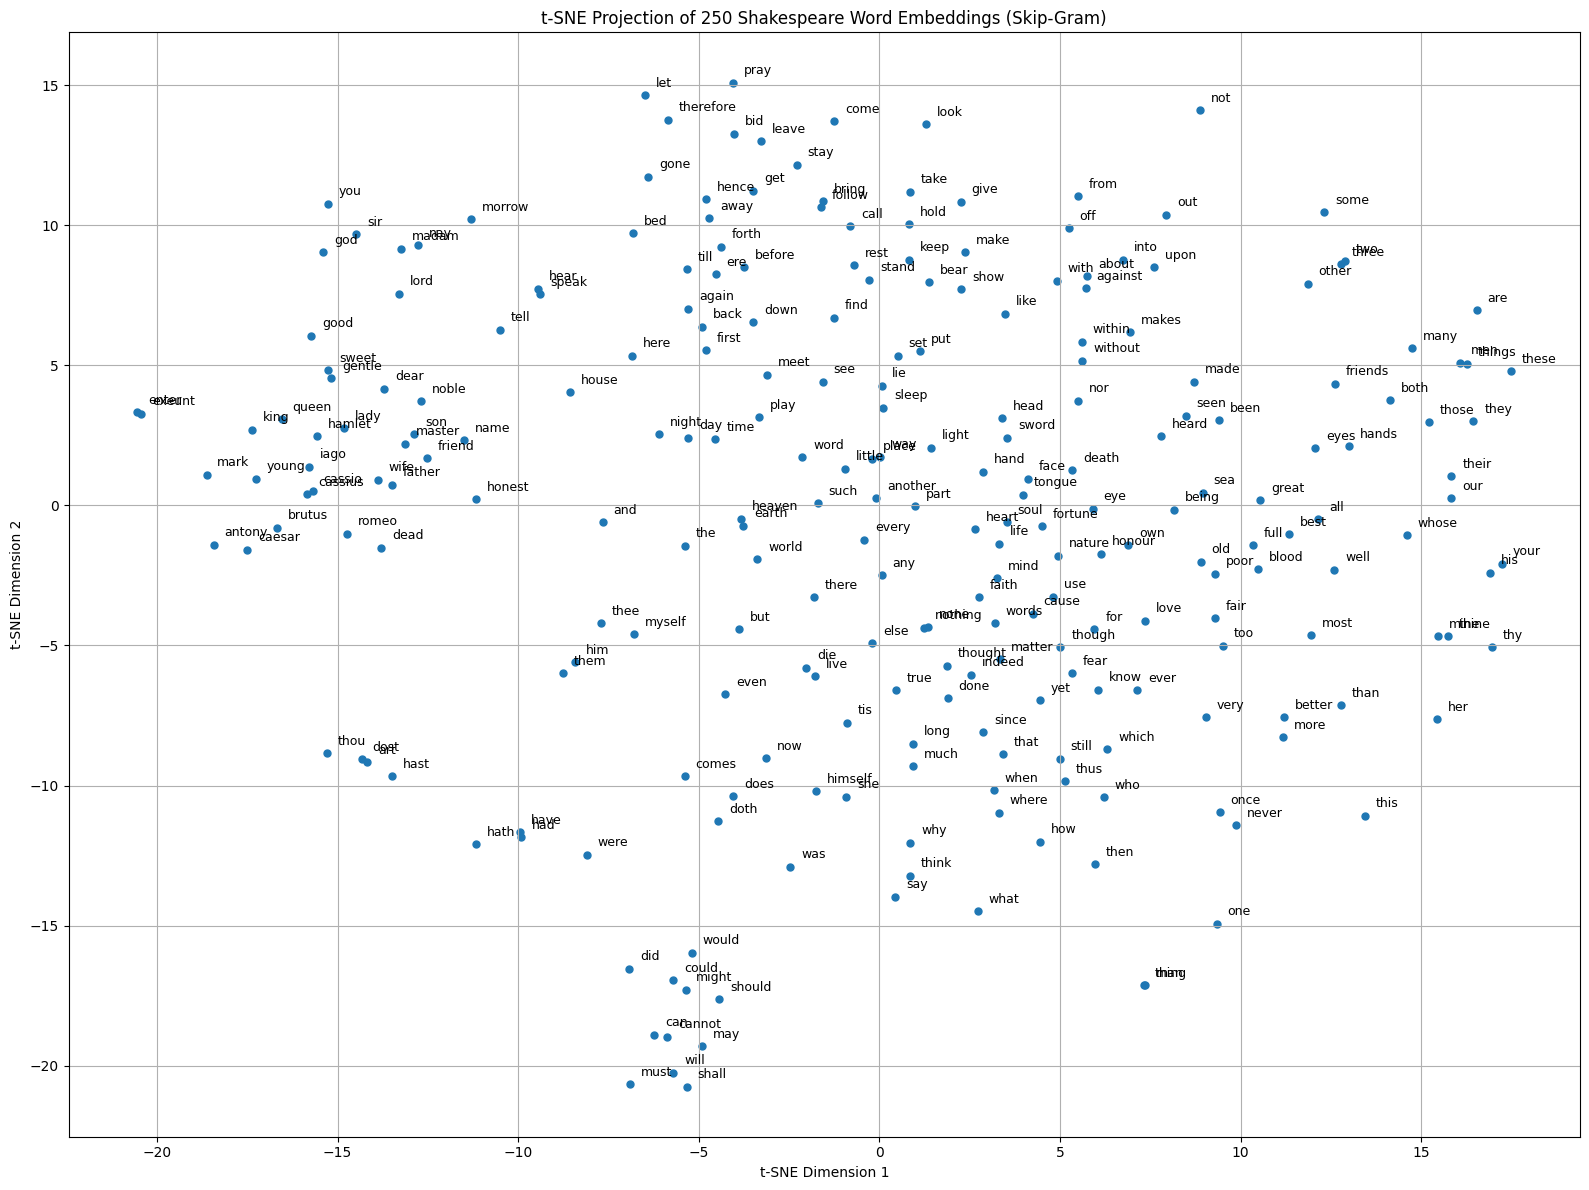

In [57]:
number_of_words_for_tsne = 250

# Use frequent, clean alphabetic words for a readable plot
plot_words = [w for w in vocab_words if w.isalpha() and len(w) > 2][:number_of_words_for_tsne]

embeddings_100 = np.array([model.wv[w] for w in plot_words])

# -----------------------------
# t-SNE projection
# -----------------------------
tsne = TSNE(
    n_components=2,
    perplexity=20,
    learning_rate="auto",
    init="pca",
    random_state=SEED
)

embeddings_2d = tsne.fit_transform(embeddings_100)

plot_df = pd.DataFrame({
    "word": plot_words,
    "x": embeddings_2d[:, 0],
    "y": embeddings_2d[:, 1]
})

# -----------------------------
# Plot t-SNE
# -----------------------------
plt.figure(figsize=(16, 12))
plt.scatter(plot_df["x"], plot_df["y"], s=25)

for _, row in plot_df.iterrows():
    plt.text(row["x"] + 0.3, row["y"] + 0.3, row["word"], fontsize=9)

plt.title(f"t-SNE Projection of {number_of_words_for_tsne} Shakespeare Word Embeddings (Skip-Gram)")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.grid(True)
plt.tight_layout()
plt.show()

This visualisation shows a t-SNE projection of word embeddings learned from the Shakespeare corpus using the Skip-Gram model. Each point represents a word, and its position is determined by reducing its high-dimensional embedding (e.g., 100 dimensions) into two dimensions while preserving relative similarity. Words that appear closer together in the plot have similar contextual usage, while those far apart are used in different contexts.

Several meaningful clusters can be observed. For example, character names such as romeo, brutus, antony, and caesar appear near each other, reflecting their shared narrative roles. Function words like the, and, of tend to cluster in broader regions due to their widespread usage across contexts. Similarly, semantically related groups—such as verbs (come, go, take, give) or abstract concepts (love, honour, death)—form loose clusters. Although t-SNE does not preserve exact distances, it effectively reveals the local neighbourhood structure of the embedding space, demonstrating that the model has successfully captured semantic and contextual relationships among words.

# Cosine similarity table for n sampled words

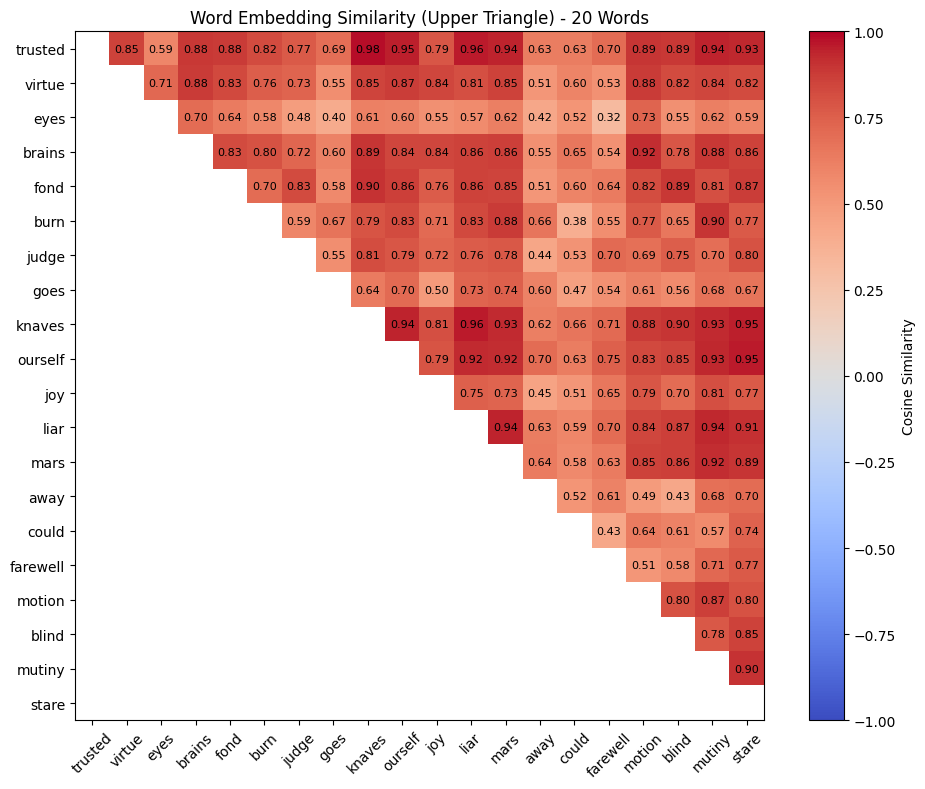

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

# Compute similarity
sample_vectors = np.array([model.wv[w] for w in sample_words])
sim_matrix = cosine_similarity(sample_vectors)

# Create mask (hide lower triangle + diagonal)
mask = np.tril(np.ones_like(sim_matrix, dtype=bool))

# Apply mask
sim_masked = np.ma.masked_where(mask, sim_matrix)

# Plot
plt.figure(figsize=(10, 8))
plt.imshow(sim_masked, cmap='coolwarm', vmin=-1, vmax=1)

# Colorbar
plt.colorbar(label="Cosine Similarity")

# Axis labels
plt.xticks(ticks=np.arange(len(sample_words)), labels=sample_words, rotation=45)
plt.yticks(ticks=np.arange(len(sample_words)), labels=sample_words)

# Annotate values
for i in range(len(sample_words)):
    for j in range(len(sample_words)):
        if not mask[i, j]:
            plt.text(j, i, f"{sim_matrix[i, j]:.2f}",
                     ha='center', va='center', fontsize=8)

plt.title(f"Word Embedding Similarity (Upper Triangle) - {number_of_words_to_display} Words")
plt.tight_layout()
plt.show()

This visualisation shows the pairwise cosine similarity between selected word embeddings, displayed as a one-sided (upper triangular) heatmap to avoid redundancy. Each cell represents how similar two words are in the learned embedding space: values close to 1 (deep red) indicate strong similarity (words used in similar contexts), while lower values (lighter shades) indicate weaker relationships. Since cosine similarity measures the angle between vectors, high values mean the words tend to appear in similar linguistic environments in Shakespeare's text.

Several interesting patterns emerge. Words like trusted, virtue, fond, and brains show consistently high similarity with many others, suggesting they occur in rich and overlapping contexts, possibly tied to themes like character traits and human qualities. Clusters can also be seen among words such as liar, knaves, and mutiny, reflecting a shared semantic field of conflict or deceit. In contrast, words like eyes or away show relatively lower similarity with some groups, indicating more specific or distinct usage patterns. Overall, the matrix demonstrates that the Skip-Gram model has organised words into a meaningful geometric space, where semantic relationships are captured as degrees of similarity between vectors.